In [73]:
# Import packages
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
# Import data
df = pd.read_csv(Path('data/processed') / 'panel_data.csv')

In [75]:
# Take a look at dataframe
df.head()

,country,year,log_gdppc_growth,rgdpe,rgdp_pc,tariff,tariff_sd,tariff_lag1,tariff_lag2,trade_gdp,income_group
0,Albania,1997,-20.280174,12118.621094,3752.290053,13.2750,6.1875,NaN,NaN,44.729378,Low-income countries
1,Albania,2000,10.814410,14723.368164,4650.246345,9.9825,5.1525,13.2750,NaN,61.609261,Lower-middle-income countries
2,Albania,2001,9.658316,16123.092773,5121.786758,9.9775,5.1350,9.9825,13.2750,64.247446,Lower-middle-income countries
3,Albania,2002,7.413915,17287.470703,5515.942322,7.2550,4.6375,9.9775,9.9825,65.991465,Lower-middle-income countries
4,Albania,2003,10.337221,19072.255859,6116.650928,7.1225,4.8900,7.2550,9.9775,64.823215,Lower-middle-income countries


In [76]:
def line_plot(df, variable):
    '''Plot the average of a variable by year over the time period.'''
    
    # Ensure variable is numeric
    df[variable] = pd.to_numeric(df[variable], errors='coerce')
    
    # Group by year and compute average
    year_avg = df.groupby('year')[variable].mean()

    # Create line plot
    plt.figure(figsize=(6, 3))
    plt.plot(year_avg.index, year_avg.values)
    plt.xlabel('Year')
    plt.ylabel(f'Average {variable}')
    plt.title(f'Average {variable} over time')
    plt.show()

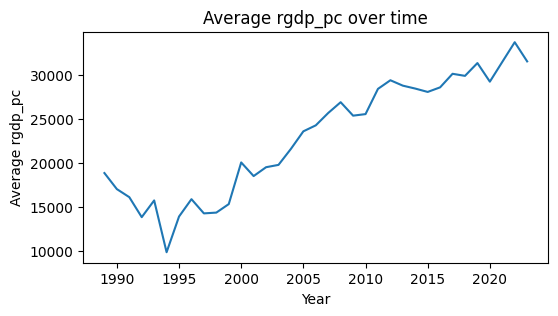

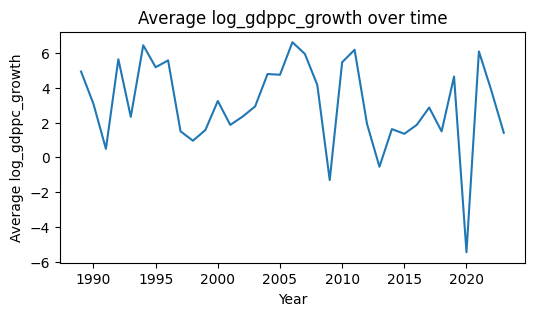

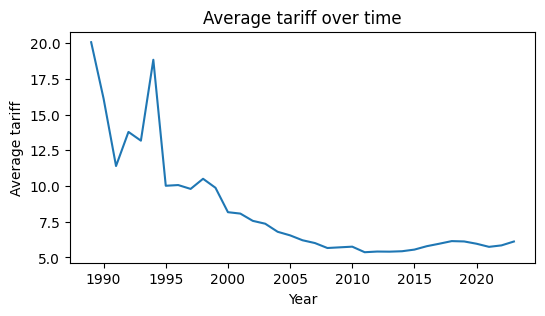

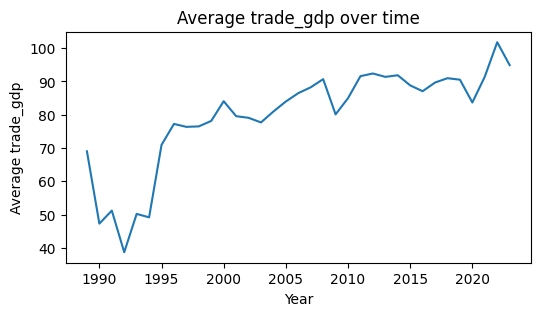

In [77]:
# Make plots of variables
line_plot(df, 'rgdp_pc')
line_plot(df, 'log_gdppc_growth')
line_plot(df, 'tariff')
line_plot(df, 'trade_gdp')

In [78]:
def scatter_plot(df, x_var, y_var, x_cap_quantile = 1, y_cap_quantile = 1):
    '''Create a scatter plot of two variables.'''
    
    # Ensure variable is numeric 
    df[x_var] = pd.to_numeric(df[x_var], errors='coerce')
    df[y_var] = pd.to_numeric(df[y_var], errors='coerce')


    # Optionally cap axes at a high quantile to reduce impact of extreme outliers
    if x_cap_quantile is not None:
        x_cap = df[x_var].quantile(x_cap_quantile)
        df = df[df[x_var] <= x_cap]

    if y_cap_quantile is not None:
        y_cap = df[y_var].quantile(y_cap_quantile)
        df = df[df[y_var] <= y_cap]

    # Create scatter plot
    plt.figure(figsize=(6, 3))
    plt.scatter(df[x_var], df[y_var])
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.title(f'{y_var} vs {x_var}')
    plt.show()

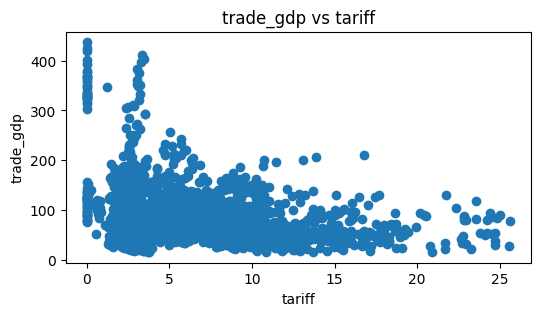

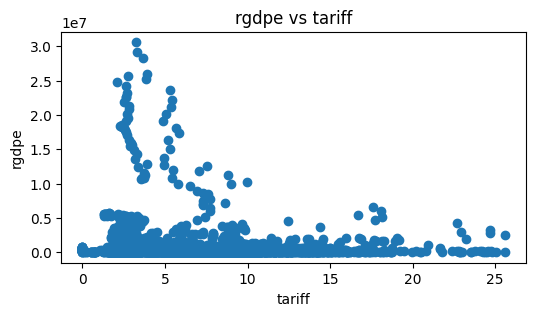

In [79]:
# Create scatter plot with tariffs and trade as % of GDP
scatter_plot(df, 'tariff', 'trade_gdp', 0.99)

# Create scatter plot with real tariffs and trade as % of GDP
scatter_plot(df, 'tariff', 'rgdpe', 0.99)

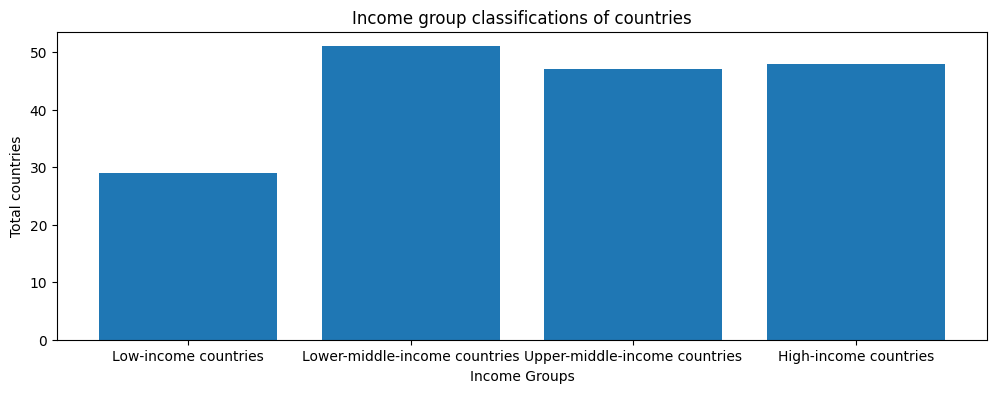

In [80]:
# Create histogram with income group distribution (includes countries whose classification changes)
# One row per country–income group combination
unique_countries = df[['country', 'income_group']].drop_duplicates()

# Define correct income ordering
income_order = [
    'Low-income countries',
    'Lower-middle-income countries',
    'Upper-middle-income countries',
    'High-income countries'
]

# Count countries per income group and reindex to enforce order
counts = (
    unique_countries['income_group']
    .value_counts()
    .reindex(income_order)
)

# Plot
plt.figure(figsize=(12, 4))
plt.bar(counts.index, counts.values)
plt.xlabel('Income Groups')
plt.ylabel('Total countries')
plt.title('Income group classifications of countries')
plt.show()